In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re
from wordcloud import WordCloud


/var/folders/g9/_yq754fd4036z7p0lpv64m3r0000gn/T/ipykernel_84492/2995907555.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  corn = pd.read_csv("cornell_combined.csv")


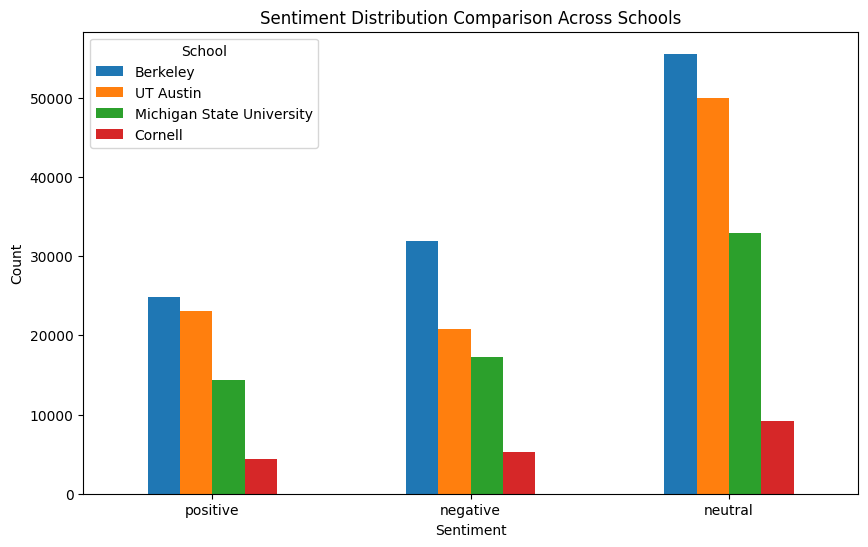

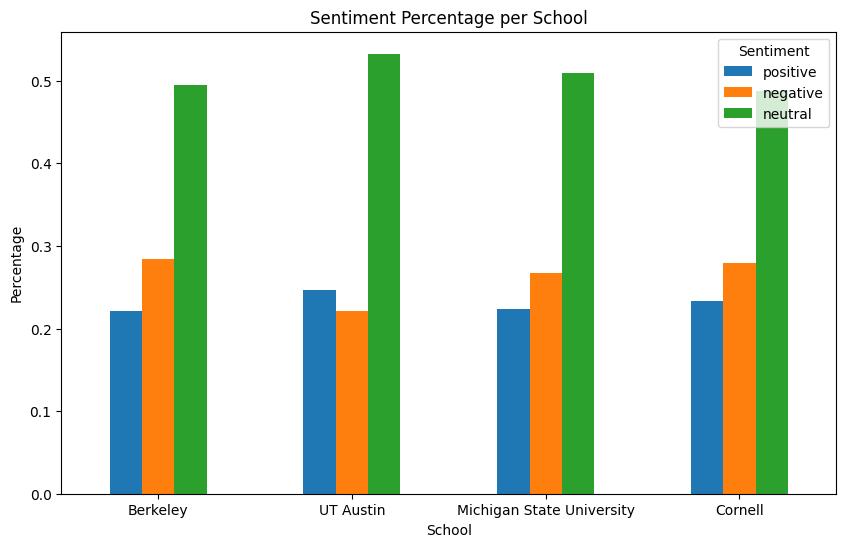

In [ ]:
berk = pd.read_csv("berkeley_combined.csv") 
uta = pd.read_csv("uta_combined.csv")
msu = pd.read_csv("msu_combined.csv")
corn = pd.read_csv("cornell_combined.csv")

def sentiment_distribution(df, school_name):
    sentiment_counts = df['sentiment_label'].value_counts()
    plt.figure(figsize=(8, 5))
    sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
    plt.title(f'Sentiment Distribution for {school_name}')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

def assign_sentiment(row):
    sentiments = {
        'positive': row['emo_pred_pos'],
        'negative': row['emo_pred_neg'],
        'neutral': row['emo_pred_neu'],
    }
    return max(sentiments, key=sentiments.get)

if 'sentiment_label' not in berk.columns:
    berk['sentiment_label'] = berk.apply(assign_sentiment, axis=1)
if 'sentiment_label' not in uta.columns:
    uta['sentiment_label'] = uta.apply(assign_sentiment, axis=1)
if 'sentiment_label' not in msu.columns:
    msu['sentiment_label'] = msu.apply(assign_sentiment, axis=1)
if 'sentiment_label' not in corn.columns:
    corn['sentiment_label'] = corn.apply(assign_sentiment, axis=1)


schools = {
    'Berkeley': berk,
    'UT Austin': uta,
    'Michigan State University': msu,
    'Cornell': corn
}

sentiments = ['positive', 'negative', 'neutral']
sentiment_counts = {school: df['sentiment_label'].value_counts() for school, df in schools.items()}

sentiment_df = pd.DataFrame(sentiment_counts).reindex(sentiments).fillna(0)

sentiment_df.plot(kind='bar', figsize=(10, 6))
plt.title('Sentiment Distribution Comparison Across Schools')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='School')
plt.show()

sentiment_percentage = sentiment_df.div(sentiment_df.sum(axis=0), axis=1)

sentiment_percentage.T.plot(kind='bar', figsize=(10, 6))
plt.title('Sentiment Percentage per School')
plt.xlabel('School')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.show()

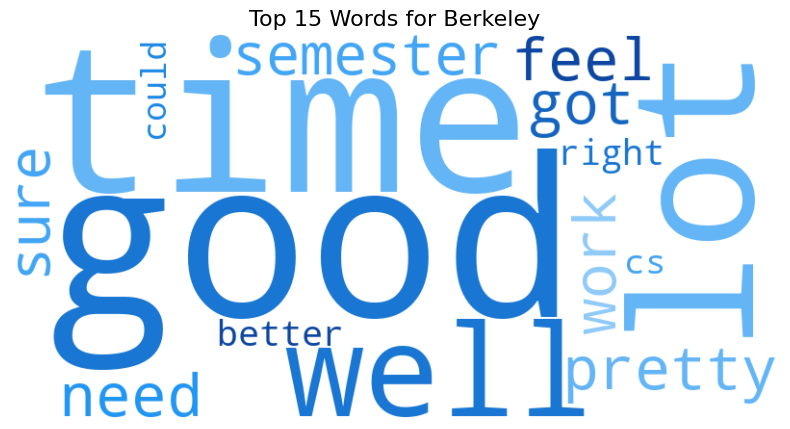

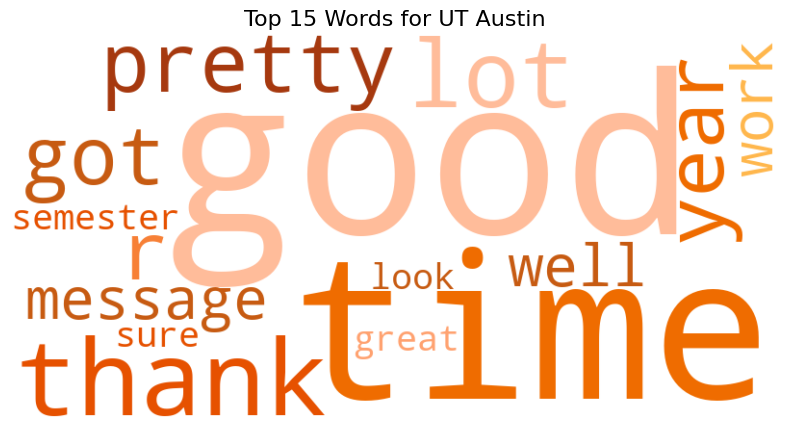

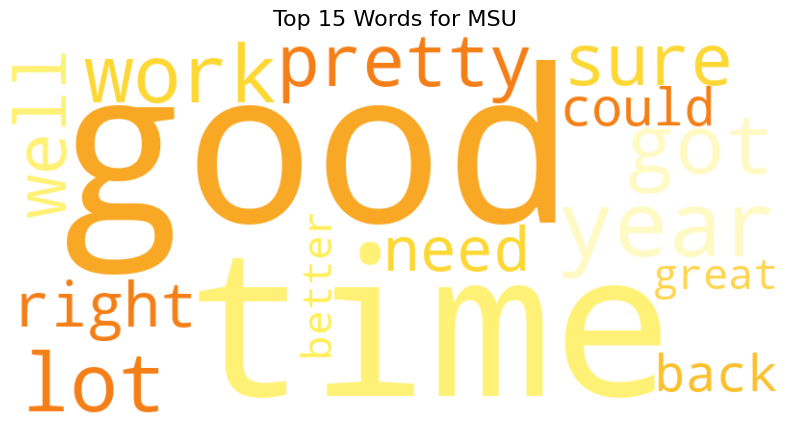

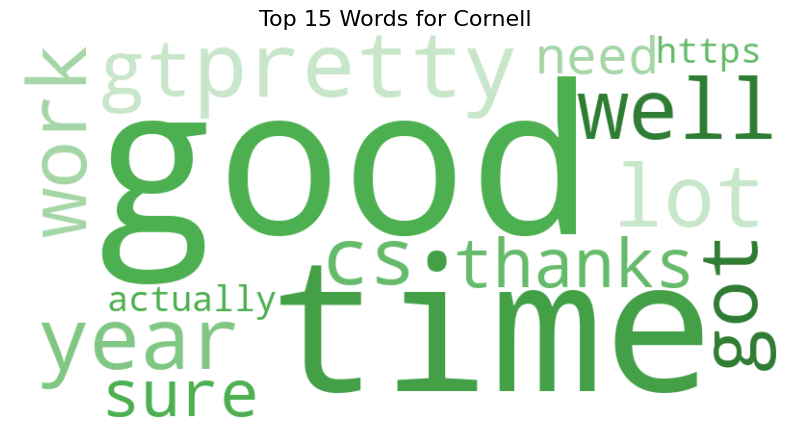

In [49]:
import random

# 1. Text cleaning
stop_words = set(stopwords.words('english'))
custom_exclude = {
    "cornell", "would", "also", "get", "like", "people", "one", "even", "much", "many", "think",
    "class", "students", "something", "anything", "thing", "things", "really", "know",
    "way", "make", "made", "going", "go", "say", "said", "see", "seen", "still", "take",
    "taken", "want", "wanted", 'berkeley','msu','austin', 'ut', 'texas', 'university', 'of', 'the', 'and', 'in', 'to', 'for', 'is', 'that', 'it', 'this',
    'campus', 'students', 'student', 'school', 'college', 'professor', 'professors', 'classroom',
    'classes', 'course', 'courses', 'degree', 'degrees', 'major', 'majors', 'program', 'programs',
    'research', 'project', 'projects', 'study', 'studies', 'academic', 'academics',
    'faculty', 'staff', 'administration', 'administrators', 'department', 'departments',
    'undergraduate', 'graduate', 'postgraduate', 'alumni', 'alumnus', 'alumna', 'alumnae',
    'campus', 'community', 'environment', 'culture', 'tradition', 'traditions', 'history',
    'heritage', 'legacy', 'values', 'mission', 'vision', 'goals', 'objectives',
    'curriculum', 'syllabus', 'textbook', 'textbooks', 'reading' 
}

def get_words(text):
    words = re.findall(r'\b\w+\b', str(text).lower())
    return [word for word in words if word not in stop_words and word not in custom_exclude]

def blue_shades(*args, **kwargs):
    return random.choice([
        '#0d47a1', '#1976d2', '#42a5f5', '#90caf9', '#bbdefb',
        '#1565c0', '#1e88e5', '#64b5f6', '#2196f3'
    ])

def green_shades(*args, **kwargs):
    return random.choice([
        '#1b5e20', '#388e3c', '#66bb6a', '#a5d6a7', '#c8e6c9',
        '#2e7d32', '#43a047', '#81c784', '#4caf50'
    ])

def yellow_shades(*args, **kwargs):
    return random.choice([
        '#f57f17', '#f9a825', '#fdd835', '#fff176', '#ffee58',
        '#fbc02d', '#ffd54f', '#fff59d', '#fff9c4'
    ])

def burnt_orange_shades(*args, **kwargs):  # UT Austin-style
    return random.choice([
        '#a6390f', '#c75b12', '#f78036', '#ffa270', '#ffbc9a',
        '#e65100', '#ef6c00', '#fb8c00', '#ffb74d'
    ])

school_colors = {
    'Berkeley': blue_shades,
    'Cornell': green_shades,
    'MSU': yellow_shades,
    'UT Austin': burnt_orange_shades,
}

# 3. Collect word counts per school
school_word_counts = {}

for school_name, df in schools.items():
    pos_words = Counter()
    neg_words = Counter()
    
    for _, row in df.iterrows():
        words = get_words(row['body'])
        if row.get('sentiment_label') == 'positive':
            pos_words.update(words)
        elif row.get('sentiment_label') == 'negative':
            neg_words.update(words)
    
    # Combine pos and neg word counts
    total_words = pos_words + neg_words
    top_10_words = dict(total_words.most_common(15))
    
    school_word_counts[school_name] = top_10_words

# 4. Generate word clouds
for school_name, top_words in school_word_counts.items():
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate_from_frequencies(top_words)
    color_func = school_colors.get(school_name, lambda *args, **kwargs: "pink")
    wordcloud.recolor(color_func=color_func)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top 15 Words for {school_name}', fontsize=16)
    plt.show()


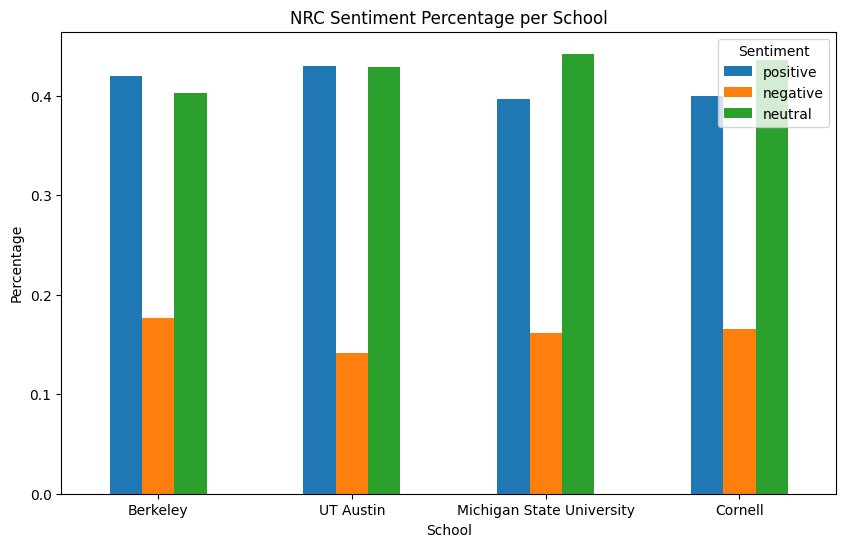

In [ ]:
#in percentage using NRC sentiment
nrc_sentiment_percentage = nrc_sentiment_df.div(nrc_sentiment_df.sum(axis=0), axis=1)

nrc_sentiment_percentage.T.plot(kind='bar', figsize=(10, 6))
plt.title('NRC Sentiment Percentage per School')
plt.xlabel('School')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.show()

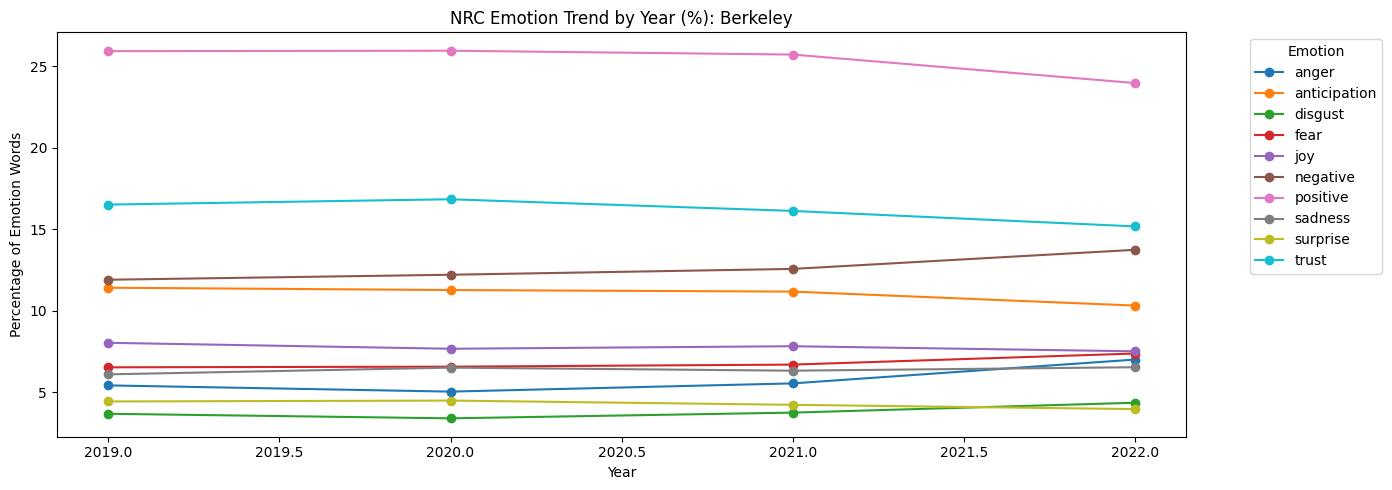

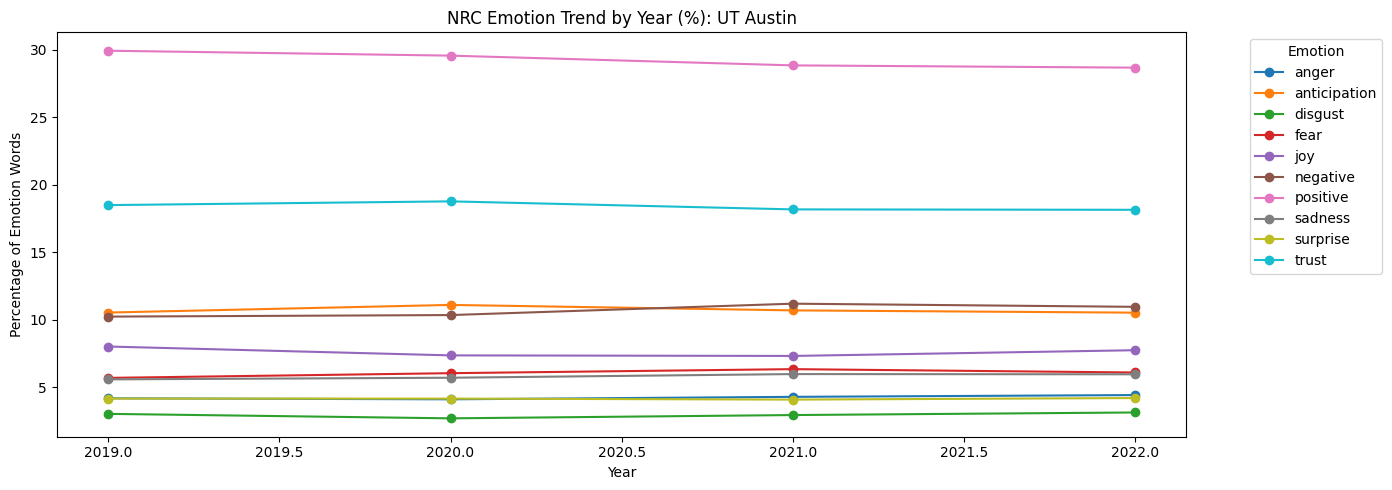

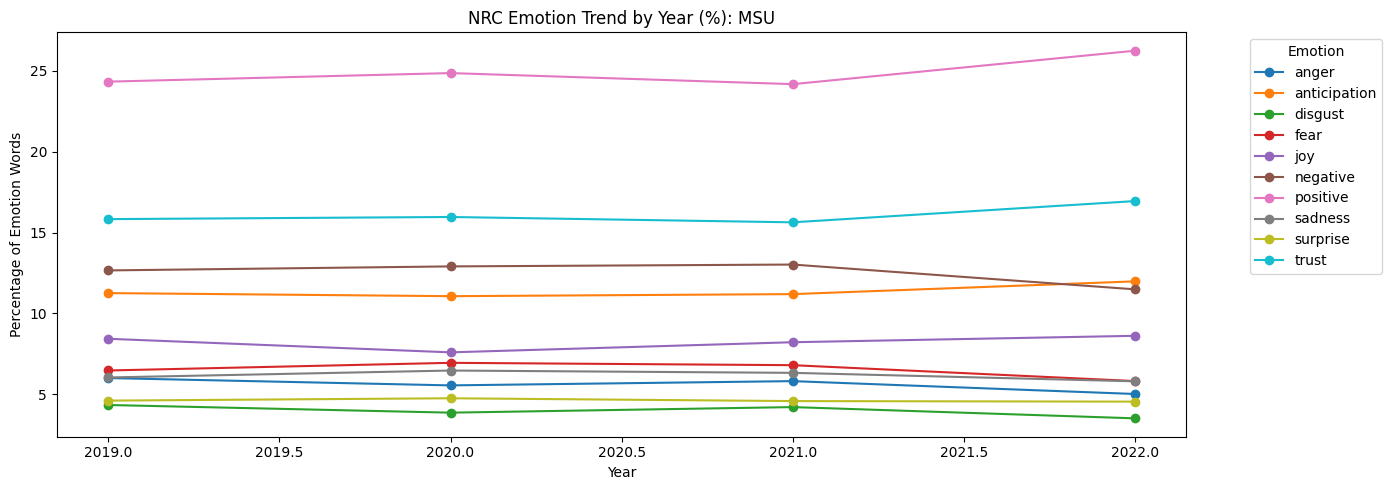

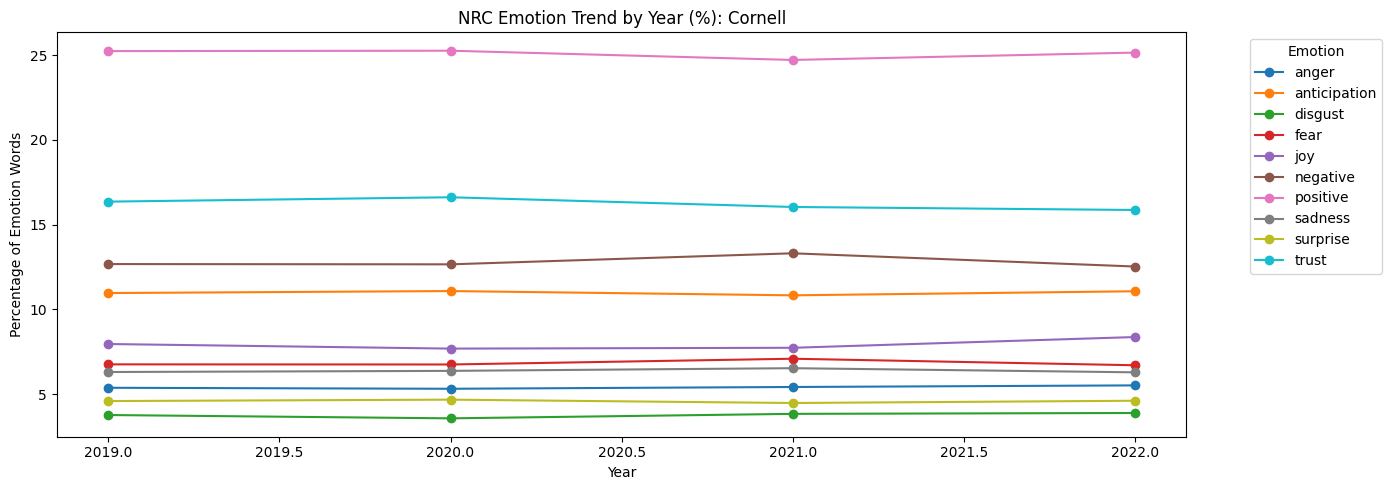

In [38]:
# Load NRC lexicon
nrc_df = pd.read_csv("nrc_lexicon.txt", sep="\t", names=["word", "emotion", "association"])
nrc_df = nrc_df[nrc_df["association"] == 1]

# Build dictionary: word → list of emotions
nrc_emotion_dict = defaultdict(list)
for _, row in nrc_df.iterrows():
    nrc_emotion_dict[row["word"]].append(row["emotion"])

# Define schools dictionary (make sure df has 'year' and 'body' columns)
schools = {
    'Berkeley': berk,
    'UT Austin': uta,
    'MSU': msu,
    'Cornell': corn
}

# Store results in a multi-index DataFrame: (School, Year) × Emotion
results = []

for school_name, school_df in schools.items():
    for _, row in school_df.iterrows():
        year = row['year']
        words = re.findall(r'\b\w+\b', str(row['body']).lower())
        emotions_this_post = Counter()
        for word in words:
            if word in nrc_emotion_dict:
                emotions_this_post.update(nrc_emotion_dict[word])
        
        for emotion, count in emotions_this_post.items():
            results.append((school_name, year, emotion, count))

# Convert to DataFrame
emotion_df = pd.DataFrame(results, columns=["school", "year", "emotion", "count"])

# Pivot: index=(school, year), columns=emotion
pivot_df = emotion_df.pivot_table(
    index=["school", "year"],
    columns="emotion",
    values="count",
    aggfunc="sum"
).fillna(0)

# Compute percentage by row (row = a school's year)
emotion_pct_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# Plot per school
for school in schools:
    school_df = emotion_pct_df.loc[school]
    ax = school_df.sort_index().plot(kind="line", marker='o', figsize=(14, 5))
    plt.title(f"NRC Emotion Trend by Year (%): {school}")
    plt.xlabel("Year")
    plt.ylabel("Percentage of Emotion Words")
    plt.legend(title="Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()